<a href="https://colab.research.google.com/github/Sythaz/PCVK_Ganjil_2024/blob/main/PCVK_Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: **Muhammad Syafiq Aldiansyah**

Kelas: **3A - 21**

NIM: **2341720102**

# **Praktikum**

## ***Nomor 2 - A & B***

In [18]:
# Hubungkan Google Colab dengan Google Drive.
from google.colab import drive
drive.mount('/content/drive')

# Impor library yang akan digunakan.
# numpy (np) -> untuk operasi matriks (gambar dan kernel).
import numpy as np
# matplotlib.pyplot (plt) -> untuk menampilkan gambar dan hasil.
import matplotlib.pyplot as plt
# cv2 (cv) -> untuk memuat gambar dan konversi warna.
import cv2 as cv
# math -> untuk operasi matematika (digunakan untuk generate kernel gaussian).
import math
# cv2_imshow -> untuk menampilkan gambar di notebook Colab.
from google.colab.patches import cv2_imshow
# PIL (im) -> alternatif untuk manipulasi gambar.
from PIL import Image as im

# Path gambar
file_path_female = '/content/drive/MyDrive/PCVK/Images/female.jpg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***Nomor 1 dan Nomor 2 - C***
Jawabannya sama, membuat konvolusi 2D secara manual

In [19]:
# FUNGSI KONVOLUSI 2D MANUAL

# Fungsi ini akan melakukan operasi konvolusi pada sebuah 'image'
# menggunakan sebuah 'kernel' yang diberikan.
# Parameter sesuai permintaan modul: citra masukan, kernel, stride, dan padding.
def convolution2d(image, kernel, stride, padding):

    # Balik kernel secara horizontal dan vertikal.
    # Operasi konvolusi secara matematis memerlukan kernel yang dibalik.
    kernel = np.flipud(np.fliplr(kernel))

    # Ambil dimensi dari gambar dan kernel.
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Terapkan padding (zero-padding) ke gambar.
    # Ini adalah salah satu solusi untuk menangani 'efek menggantung' di pinggir citra.
    padded_img_height = img_height + 2 * padding
    padded_img_width = img_width + 2 * padding
    padded_image = np.zeros((padded_img_height, padded_img_width))
    # Salin nilai piksel gambar asli ke tengah matriks nol tersebut.
    padded_image[padding:-padding, padding:-padding] = image

    # Hitung dimensi output.
    output_height = (padded_img_height - kernel_height) // stride + 1
    output_width = (padded_img_width - kernel_width) // stride + 1
    output_image = np.zeros((output_height, output_width))

    # Lakukan proses konvolusi dengan perulangan (loop) sesuai pseudocode.
    # Loop ini akan menggeser kernel ke seluruh bagian gambar.
    for y in range(0, output_height):
        for x in range(0, output_width):
            # Tentukan posisi awal untuk 'region of interest' (ROI) pada gambar yang dipadding.
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Ambil bagian dari gambar (ROI) yang ukurannya sama dengan kernel.
            roi = padded_image[y_start:y_end, x_start:x_end]

            # Lakukan perkalian element-wise antara ROI dan kernel, lalu jumlahkan hasilnya.
            # Inilah operasi inti dari konvolusi.
            conv_val = np.sum(roi * kernel)

            # Simpan hasil perhitungan ke matriks output.
            output_image[y, x] = conv_val

    # Kembalikan gambar hasil konvolusi.
    return output_image

## ***Nomor 2 - D***
PENERAPAN FILTER MENGGUNAKAN FUNGSI KONVOLUSI



In [20]:
# Muat gambar dan ubah menjadi citra keabuan (grayscale).
img = cv.imread(file_path_female)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

## ***Nomor 2 - E***
PENERAPAN FILTER MENGGUNAKAN FUNGSI KONVOLUSI



In [21]:
# Definisikan semua kernel yang akan digunakan sesuai modul.

# Sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Emboss
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

# Left Sobel Edge Detection
kernel_sobel = np.array([[1, 0, -1],
                         [2, 0, -2],
                         [1, 0, -1]])

# Canny Edge Detection (Laplacian/LOG Kernel)
kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

# Prewitt Edge Detection
kernel_prewitt = np.array([[-1, -1, -1],
                           [0, 0, 0],
                           [1, 1, 1]])

# 5x5 Gaussian Blur
kernel_gaussian_5x5 = (1/256) * np.array([[1, 4, 6, 4, 1],
                                          [4, 16, 24, 16, 4],
                                          [6, 24, 36, 24, 6],
                                          [4, 16, 24, 16, 4],
                                          [1, 4, 6, 4, 1]])

# 21x21 Gaussian Blur (dibuat secara programatik).
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

## ***Nomor 2 - F***
PENERAPAN FILTER MENGGUNAKAN FUNGSI KONVOLUSI



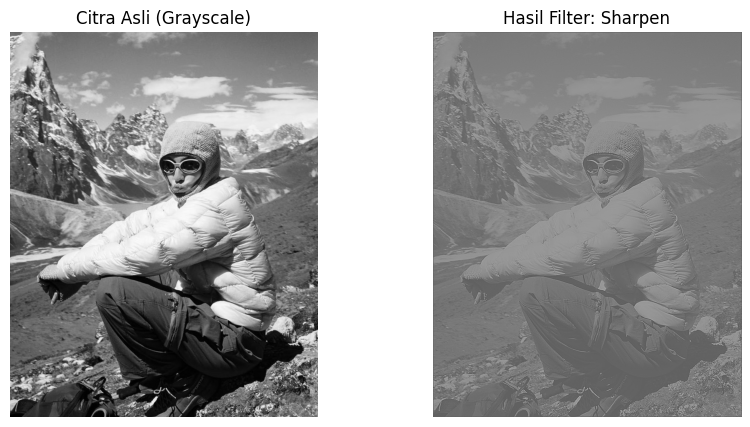

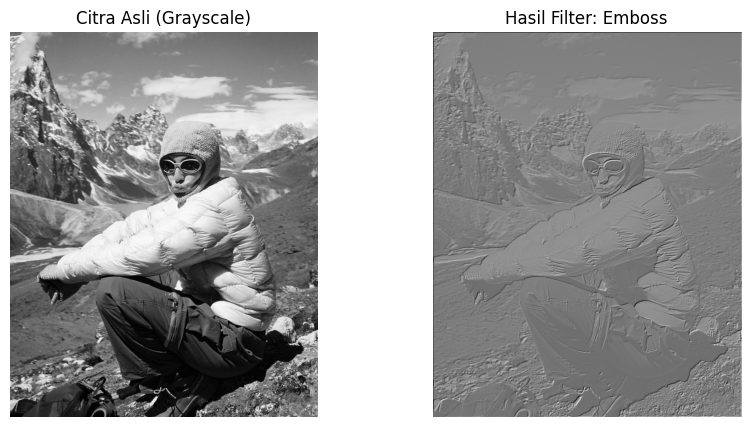

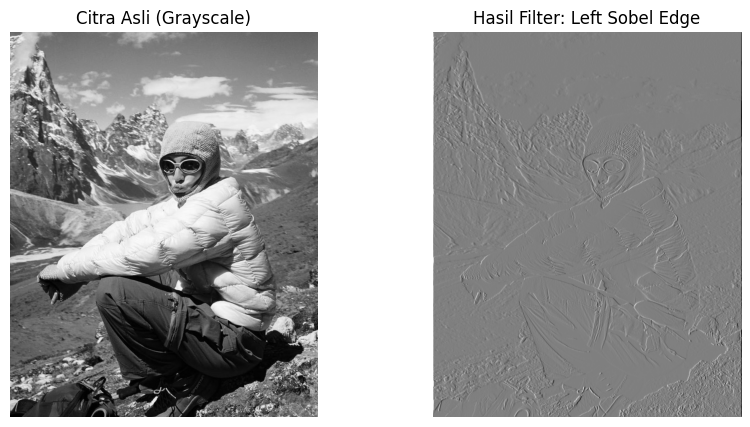

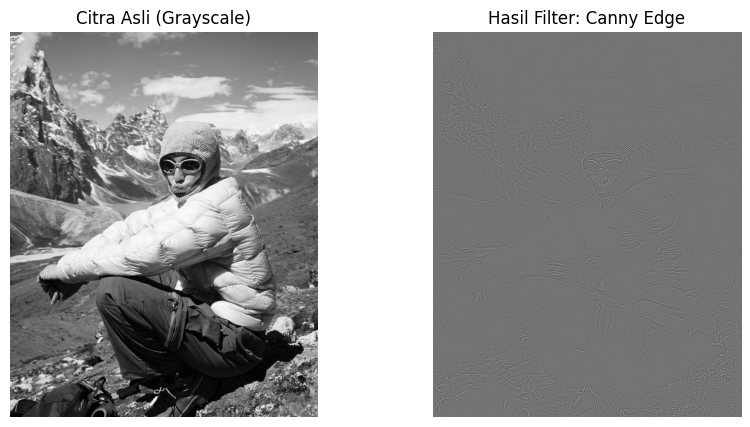

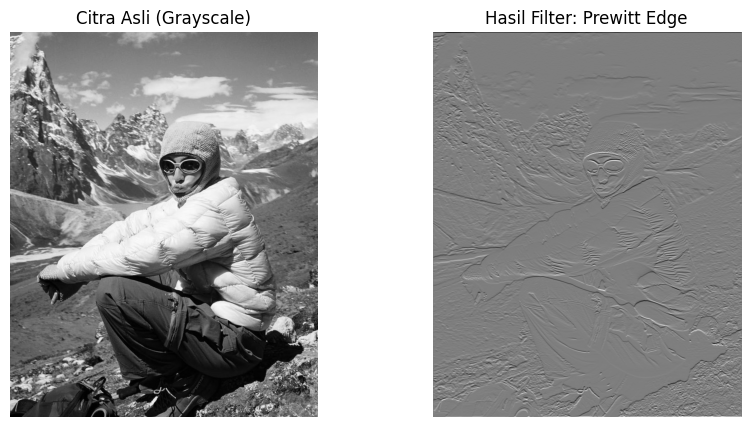

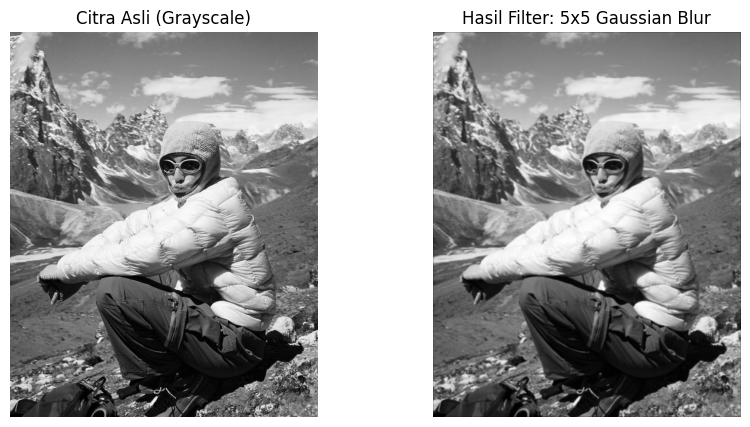

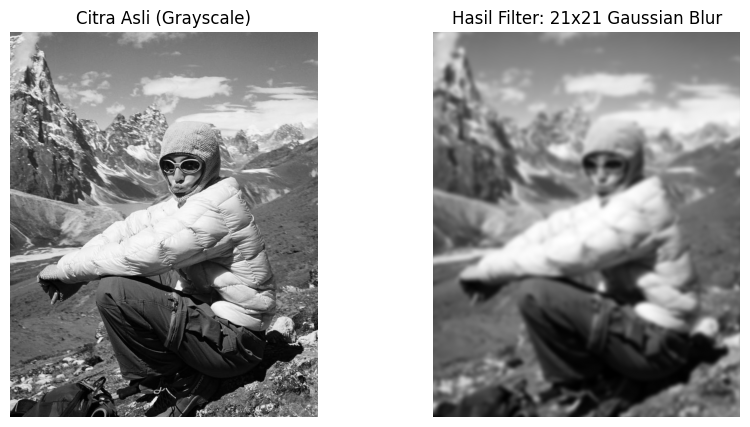

In [22]:
# Panggil fungsi konvolusi untuk setiap kernel dan tampilkan hasilnya.
# Stride=1 dan padding disesuaikan agar ukuran output sama dengan input.

# Buat dictionary untuk menyimpan kernel dan namanya agar mudah di-loop.
filters = {
    "Sharpen": kernel_sharpen,
    "Emboss": kernel_emboss,
    "Left Sobel Edge": kernel_sobel,
    "Canny Edge": kernel_canny,
    "Prewitt Edge": kernel_prewitt,
    "5x5 Gaussian Blur": kernel_gaussian_5x5,
    "21x21 Gaussian Blur": kernel_gaussian_21x21
}

# Lakukan konvolusi dan tampilkan hasil untuk setiap filter.
for name, kernel in filters.items():
    # Terapkan konvolusi menggunakan fungsi yang telah dibuat. sesuai di modul
    filtered_image = convolution2d(img_gray, kernel, 1, 2)

    # Tampilkan gambar asli dan hasilnya berdampingan untuk perbandingan.
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Citra Asli (Grayscale)')
    axes[0].axis('off')

    axes[1].imshow(filtered_image, cmap='gray')
    axes[1].set_title(f'Hasil Filter: {name}')
    axes[1].axis('off')

    plt.show()

## ***Nomor 3***
PENERAPAN FILTER:
- Average filter
- low pass filter
- high pass filter
- Sharpen
- Emboss
- Left Sobel Edge Detection
- Canny Edge Detection
- Prewitt Edge Detection
- 5x5 Gaussian Blur
- 21x21 Gaussian Blur



In [23]:
# Muat gambar dan ubah menjadi citra keabuan (grayscale).
img = cv.imread(file_path_female) # Pastikan `file_path_female` sudah didefinisikan.
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [24]:
# Definisikan SEMUA kernel

# Average Filter
kernel_average = (1/9) * np.array([[1, 1, 1],
                                   [1, 1, 1],
                                   [1, 1, 1]])

# Low Pass Filter
kernel_low_pass = (1/12) * np.array([[1, 1, 1],
                                     [1, 4, 1],
                                     [1, 1, 1]])

# High Pass Filter
kernel_high_pass = np.array([[-1, 0, 1],
                             [-1, 0, 3],
                             [-3, 0, 1]])

# Sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Emboss
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

# Left Sobel Edge Detection
kernel_sobel = np.array([[1, 0, -1],
                         [2, 0, -2],
                         [1, 0, -1]])

# Canny Edge Detection (Laplacian/LOG Kernel)
kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

# Prewitt Edge Detection
kernel_prewitt = np.array([[-1, -1, -1],
                           [0, 0, 0],
                           [1, 1, 1]])

# 5x5 Gaussian Blur
kernel_gaussian_5x5 = (1/256) * np.array([[1, 4, 6, 4, 1],
                                          [4, 16, 24, 16, 4],
                                          [6, 24, 36, 24, 6],
                                          [4, 16, 24, 16, 4],
                                          [1, 4, 6, 4, 1]])

# 21x21 Gaussian Blur (dibuat secara programatik).
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

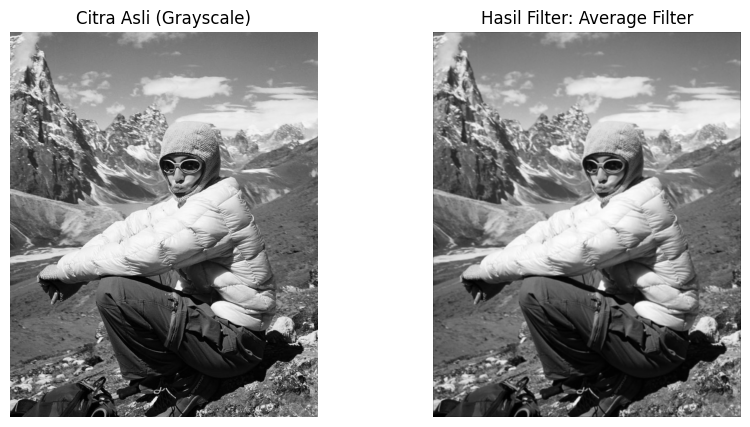

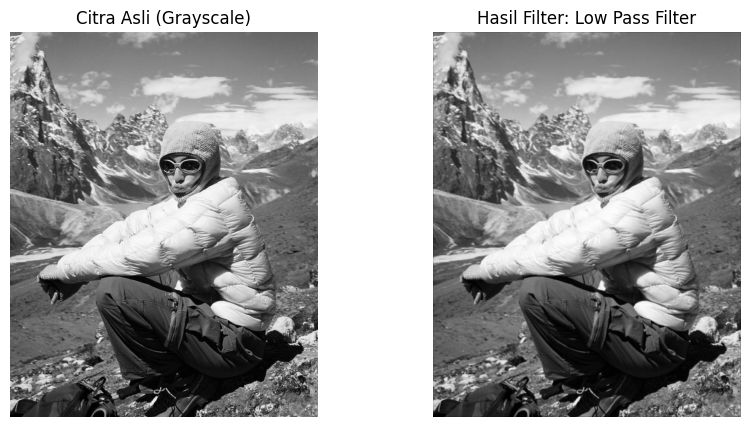

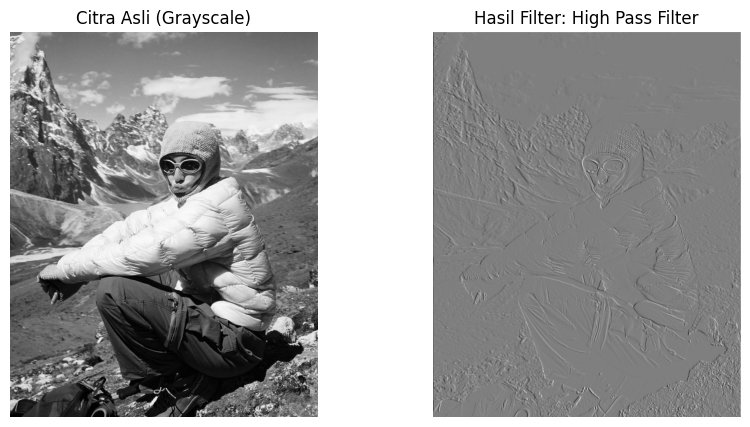

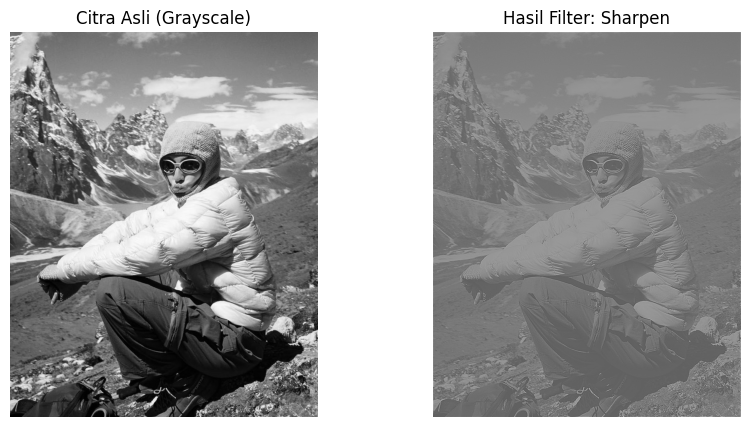

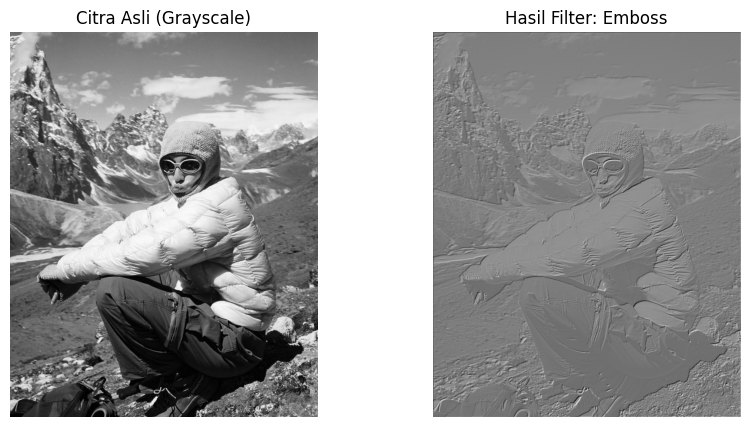

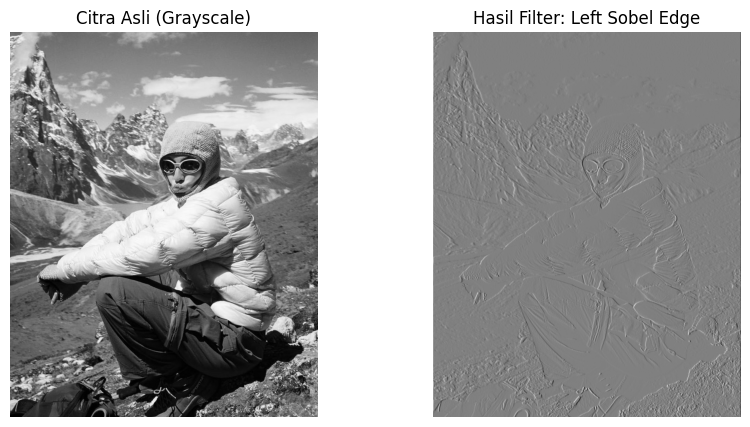

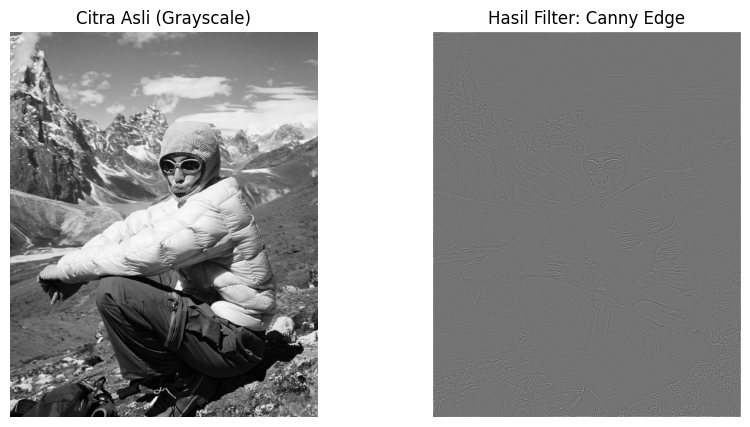

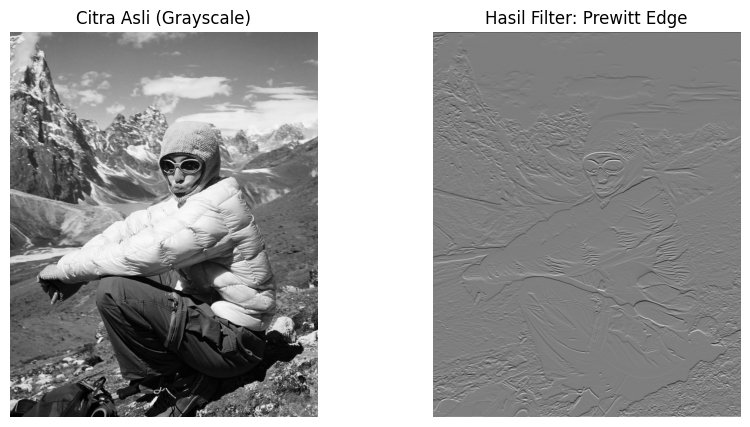

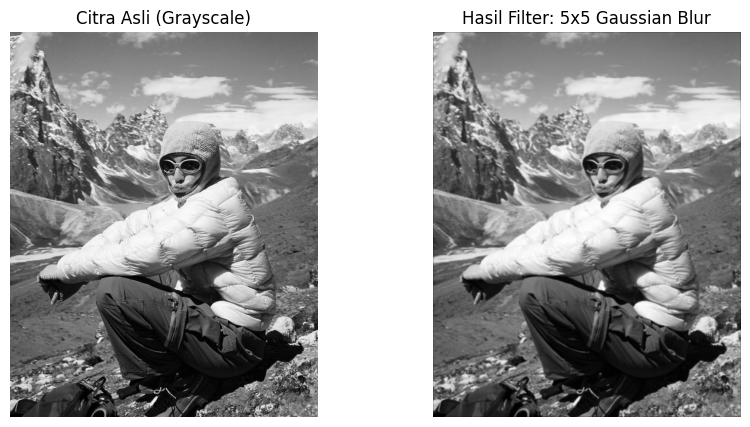

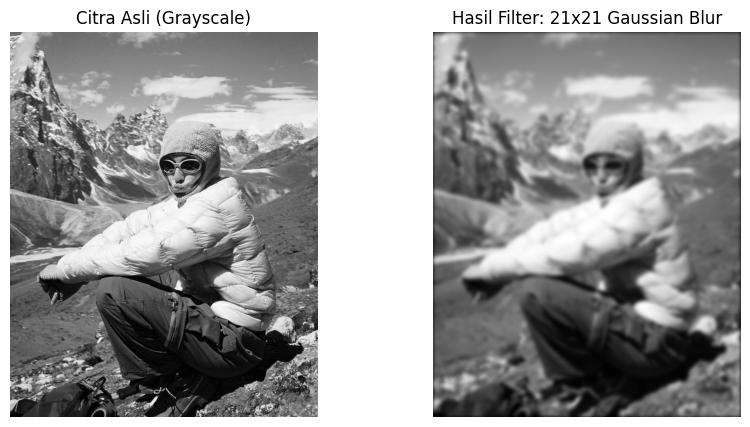

In [25]:
# Implementasi filterny

# Buat dictionary yang berisi semua filter untuk kemudahan iterasi.
all_filters = {
    "Average Filter": kernel_average,
    "Low Pass Filter": kernel_low_pass,
    "High Pass Filter": kernel_high_pass,
    "Sharpen": kernel_sharpen,
    "Emboss": kernel_emboss,
    "Left Sobel Edge": kernel_sobel,
    "Canny Edge": kernel_canny,
    "Prewitt Edge": kernel_prewitt,
    "5x5 Gaussian Blur": kernel_gaussian_5x5,
    "21x21 Gaussian Blur": kernel_gaussian_21x21
}

# Lakukan konvolusi dan tampilkan hasil untuk setiap filter.
for name, kernel in all_filters.items():
    # Hitung padding yang dibutuhkan agar ukuran output sama dengan input.
    padding = kernel.shape[0] // 2

    # Terapkan konvolusi menggunakan fungsi manual kita.
    filtered_image = convolution2d(img_gray, kernel, 1, padding)

    # Tampilkan gambar asli dan hasilnya berdampingan.
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Citra Asli (Grayscale)')
    axes[0].axis('off')

    axes[1].imshow(filtered_image, cmap='gray')
    axes[1].set_title(f'Hasil Filter: {name}')
    axes[1].axis('off')

    plt.show()